In [1]:
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Literal
from pydantic import BaseModel, Field
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

In [3]:
import pickle
import numpy as np

class TemperatureScalerFit:
    def __init__(self):
        self.temperature = 1.0

    def fit(self, probs, true_labels):
        return self

    def predict_proba(self, probs):
        probs = np.asarray(probs, dtype=float)
        eps = 1e-12
        logits = np.log((probs + eps) / (1 - probs + eps))
        scaled = 1 / (1 + np.exp(-(logits / self.temperature)))
        return np.clip(scaled, 0.0, 1.0)

class ArtifactUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == "__main__" and name == "TemperatureScalerFit":
            return TemperatureScalerFit
        return super().find_class(module, name)

ARTIFACT_PATH = "diverse_week5_artifacts.pkl"

with open(ARTIFACT_PATH, "rb") as f:
    artifacts = ArtifactUnpickler(f).load()

feature_columns = artifacts["feature_columns"]
lr_clf = artifacts["lr_classifier"]
rf_clf = artifacts["rf_classifier"]
lr_temp_scaler = artifacts["lr_temp_scaler"]
rf_temp_scaler = artifacts["rf_temp_scaler"]
selected_model_name = artifacts["selected_model_name"]

comparison_df = artifacts.get("comparison_df", None)
lr_val_metrics = artifacts.get("lr_val_metrics", None)
rf_val_metrics = artifacts.get("rf_val_metrics", None)
lr_test_before = artifacts.get("lr_test_before", None)
rf_test_before = artifacts.get("rf_test_before", None)
lr_test_after = artifacts.get("lr_test_after", None)
rf_test_after = artifacts.get("rf_test_after", None)

print("Loaded artifact successfully.")
print("Selected model:", selected_model_name)
print("Feature columns:", feature_columns)

Loaded artifact successfully.
Selected model: random_forest
Feature columns: ['avg_word_length', 'type_token_ratio', 'hapax_ratio', 'stopword_ratio', 'avg_words_per_sentence', 'avg_sentence_length', 'sentence_length_variance', 'paragraph_count', 'period_ratio', 'capital_letter_ratio', 'comma_ratio', 'exclamation_ratio', 'question_ratio', 'long_word_ratio']


In [4]:
human_csv = "tripadvisor_hotel_reviews.csv"
ai_csv = "ai_generated_tripadvisor_reviews_openai_diverse.csv"

human_df = pd.read_csv(human_csv)
ai_df = pd.read_csv(ai_csv)

print("Human rows:", len(human_df))
print("AI rows:", len(ai_df))
print("\nHuman columns:", list(human_df.columns))
print("AI columns:", list(ai_df.columns))

Human rows: 20491
AI rows: 5434

Human columns: ['Review', 'Rating']
AI columns: ['Review', 'label', 'length_band', 'sentiment', 'tone', 'focus_1', 'focus_2', 'rating_frame', 'structure', 'hotel_name_style', 'traveler_type', 'stay_context', 'word_count', 'opening_8_words']


In [5]:
if "Review" not in human_df.columns:
    raise ValueError(f"Human CSV must contain 'Review'. Found: {list(human_df.columns)}")

if "Review" not in ai_df.columns:
    raise ValueError(f"AI CSV must contain 'Review'. Found: {list(ai_df.columns)}")

human_eval_df = human_df[["Review"]].copy()
human_eval_df["label"] = 0

ai_eval_df = ai_df[["Review"]].copy()
ai_eval_df["label"] = 1

full_df = pd.concat([human_eval_df, ai_eval_df], ignore_index=True)
full_df = full_df.dropna(subset=["Review"]).reset_index(drop=True)

print("Combined dataset size:", len(full_df))
print(full_df["label"].value_counts())

Combined dataset size: 25925
label
0    20491
1     5434
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.4,
    stratify=full_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nAI percentage by split:")
print("Train:", round(train_df["label"].mean() * 100, 2), "%")
print("Validation:", round(val_df["label"].mean() * 100, 2), "%")
print("Test:", round(test_df["label"].mean() * 100, 2), "%")

Train size: 15555
Validation size: 5185
Test size: 5185

AI percentage by split:
Train: 20.96 %
Validation: 20.96 %
Test: 20.96 %


In [7]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "as", "is", "was", "are", "were", "be",
    "been", "being", "have", "has", "had", "do", "does", "did", "will",
    "would", "could", "should", "may", "might", "must", "can", "this",
    "that", "these", "those", "i", "you", "he", "she", "it", "we", "they"
}

GEN_PREFIX_PATTERNS = [
    r"^\s*okay[,]?\s*here[']?\s*a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*sure[,]?\s*here[']?\s*a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*here[']?\s*a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*hotel\s+review\s*:\s*",
    r"^\s*review\s*:\s*",
]

def normalize_review_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("’", "'").replace("“", '"').replace("”", '"').strip()
    for pattern in GEN_PREFIX_PATTERNS:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_stylometry_features(text: str) -> Dict[str, float]:
    text = normalize_review_text(text)

    words = re.findall(r"\b\w+\b", text.lower())
    word_count = len(words)

    if word_count == 0:
        return {col: 0.0 for col in feature_columns}

    avg_word_length = np.mean([len(w) for w in words])

    unique_words = set(words)
    type_token_ratio = len(unique_words) / word_count

    word_freq = {}
    for w in words:
        word_freq[w] = word_freq.get(w, 0) + 1
    hapax_ratio = sum(1 for w in word_freq if word_freq[w] == 1) / word_count

    stopword_ratio = sum(1 for w in words if w in STOPWORDS) / word_count

    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(re.findall(r"\b\w+\b", s)) for s in sentences]

    avg_words_per_sentence = np.mean(sentence_lengths) if sentence_lengths else 0.0
    avg_sentence_length = np.mean([len(s) for s in sentences]) if sentences else 0.0
    sentence_length_variance = np.var(sentence_lengths) if len(sentence_lengths) > 1 else 0.0

    char_count = len(text) if len(text) > 0 else 1
    period_ratio = text.count(".") / char_count
    capital_letter_ratio = sum(1 for c in text if c.isupper()) / char_count
    comma_ratio = text.count(",") / char_count
    exclamation_ratio = text.count("!") / char_count
    question_ratio = text.count("?") / char_count

    paragraphs = [p for p in text.split("\n\n") if p.strip()]
    paragraph_count = len(paragraphs) if paragraphs else 1

    long_word_ratio = sum(1 for w in words if len(w) >= 7) / word_count

    return {
        "avg_word_length": round(float(avg_word_length), 3),
        "type_token_ratio": round(float(type_token_ratio), 3),
        "hapax_ratio": round(float(hapax_ratio), 3),
        "stopword_ratio": round(float(stopword_ratio), 3),
        "avg_words_per_sentence": round(float(avg_words_per_sentence), 3),
        "avg_sentence_length": round(float(avg_sentence_length), 3),
        "sentence_length_variance": round(float(sentence_length_variance), 3),
        "paragraph_count": float(paragraph_count),
        "period_ratio": round(float(period_ratio), 4),
        "capital_letter_ratio": round(float(capital_letter_ratio), 4),
        "comma_ratio": round(float(comma_ratio), 4),
        "exclamation_ratio": round(float(exclamation_ratio), 4),
        "question_ratio": round(float(question_ratio), 4),
        "long_word_ratio": round(float(long_word_ratio), 4),
    }

print("Feature extractor ready.")

Feature extractor ready.


In [8]:
class FinalDetectionOutput(BaseModel):
    review_text: str = Field(description="Original review text")
    model_used: Literal["logistic_regression", "random_forest"] = Field(description="Classifier used")
    calibrated: bool = Field(description="Whether probability calibration was applied")
    ai_probability: float = Field(ge=0.0, le=1.0)
    ai_likeness_score: int = Field(ge=0, le=100)
    uncertainty_band: Literal["likely human-written", "uncertain", "likely AI-generated"]
    predicted_label: Literal["Human", "AI"]
    top_features: Dict[str, float]
    explanation: str

def get_uncertainty_band(score: int) -> str:
    if score <= 39:
        return "likely human-written"
    elif score <= 69:
        return "uncertain"
    else:
        return "likely AI-generated"

def get_prediction_label(ai_prob: float) -> str:
    return "AI" if ai_prob >= 0.5 else "Human"

def apply_temperature_scaling(prob: float, scaler) -> float:
    scaled = scaler.predict_proba(np.array([prob], dtype=float))
    return float(np.clip(scaled[0], 0.0, 1.0))

def rank_features_for_model(model_name: str):
    if model_name == "logistic_regression":
        importances = np.abs(lr_clf.coef_[0])
    else:
        importances = np.asarray(rf_clf.feature_importances_)

    ranked_idx = np.argsort(importances)[::-1]
    return [feature_columns[i] for i in ranked_idx]

def get_top_features_for_explanation(features: Dict[str, float], model_name: str, top_k: int = 3):
    ranked = rank_features_for_model(model_name)
    selected = {}
    for feat in ranked[:top_k]:
        selected[feat] = float(features.get(feat, 0.0))
    return selected

def run_classifier_on_features(features: Dict[str, float], model_name: str = None, use_calibration: bool = True):
    if model_name is None:
        model_name = selected_model_name

    feature_vector = pd.DataFrame([features])[feature_columns]

    if model_name == "logistic_regression":
        clf = lr_clf
        scaler = lr_temp_scaler
    elif model_name == "random_forest":
        clf = rf_clf
        scaler = rf_temp_scaler
    else:
        raise ValueError("model_name must be 'logistic_regression' or 'random_forest'")

    raw_prob = float(clf.predict_proba(feature_vector)[0, 1])

    if use_calibration:
        ai_prob = apply_temperature_scaling(raw_prob, scaler)
    else:
        ai_prob = raw_prob

    score = int(round(100 * ai_prob))
    band = get_uncertainty_band(score)
    label = get_prediction_label(ai_prob)
    top_features = get_top_features_for_explanation(features, model_name=model_name, top_k=3)

    return {
        "model_used": model_name,
        "calibrated": use_calibration,
        "ai_probability": ai_prob,
        "ai_likeness_score": score,
        "uncertainty_band": band,
        "predicted_label": label,
        "top_features": top_features,
    }

def generate_grounded_explanation(classifier_output: Dict) -> str:
    ai_prob = classifier_output["ai_probability"]
    score = classifier_output["ai_likeness_score"]
    band = classifier_output["uncertainty_band"]
    label = classifier_output["predicted_label"]
    top_features = classifier_output["top_features"]

    feature_str = ", ".join([f"{k}={round(v, 4)}" for k, v in top_features.items()])

    if label == "AI":
        return (
            f"The detector assigns an AI probability of {ai_prob:.4f} "
            f"with an AI-likeness score of {score}, which falls in the '{band}' band. "
            f"The prediction is driven by the top stylometric features {feature_str}."
        )
    else:
        return (
            f"The detector assigns an AI probability of {ai_prob:.4f} "
            f"with an AI-likeness score of {score}, which falls in the '{band}' band. "
            f"The prediction is supported by the top stylometric features {feature_str}."
        )

def detect_review_with_explanation(review_text: str, model_name: str = None, use_calibration: bool = True) -> FinalDetectionOutput:
    features = extract_stylometry_features(review_text)
    filtered_features = {col: float(features.get(col, 0.0)) for col in feature_columns}

    classifier_output = run_classifier_on_features(
        features=filtered_features,
        model_name=model_name,
        use_calibration=use_calibration,
    )

    explanation = generate_grounded_explanation(classifier_output)

    return FinalDetectionOutput(
        review_text=review_text,
        model_used=classifier_output["model_used"],
        calibrated=classifier_output["calibrated"],
        ai_probability=round(classifier_output["ai_probability"], 4),
        ai_likeness_score=classifier_output["ai_likeness_score"],
        uncertainty_band=classifier_output["uncertainty_band"],
        predicted_label=classifier_output["predicted_label"],
        top_features=classifier_output["top_features"],
        explanation=explanation,
    )

def detect_hotel_review(review_text: str) -> dict:
    result = detect_review_with_explanation(review_text)
    return result.model_dump()

print("Detector helpers ready.")

Detector helpers ready.


In [9]:
test_reviews = [
    {
        "name": "Human-like example",
        "text": "Stayed here last week. Room was clean and the location was convenient, but the breakfast was disappointing and the walls were thin."
    },
    {
        "name": "AI-like example",
        "text": "This hotel exceeded all expectations. Every amenity was thoughtfully arranged, the staff delivered impeccable service, and the stay felt seamless from check-in to checkout."
    },
    {
        "name": "Ambiguous example",
        "text": "We stayed for two nights. The bed was comfortable and the bathroom was clean, but the parking fee felt too high for what we got."
    }
]

for i, item in enumerate(test_reviews, 1):
    print("\n" + "=" * 90)
    print(f"Test {i}: {item['name']}")
    print("=" * 90)

    result = detect_review_with_explanation(item["text"])

    print("Review:", result.review_text)
    print("Model used:", result.model_used)
    print("Calibrated:", result.calibrated)
    print("AI probability:", result.ai_probability)
    print("AI-likeness score:", result.ai_likeness_score)
    print("Uncertainty band:", result.uncertainty_band)
    print("Predicted label:", result.predicted_label)
    print("Top features:", result.top_features)
    print("Explanation:", result.explanation)


Test 1: Human-like example
Review: Stayed here last week. Room was clean and the location was convenient, but the breakfast was disappointing and the walls were thin.
Model used: random_forest
Calibrated: True
AI probability: 1.0
AI-likeness score: 100
Uncertainty band: likely AI-generated
Predicted label: AI
Top features: {'capital_letter_ratio': 0.0153, 'stopword_ratio': 0.455, 'avg_word_length': 4.864}
Explanation: The detector assigns an AI probability of 1.0000 with an AI-likeness score of 100, which falls in the 'likely AI-generated' band. The prediction is driven by the top stylometric features capital_letter_ratio=0.0153, stopword_ratio=0.455, avg_word_length=4.864.

Test 2: AI-like example
Review: This hotel exceeded all expectations. Every amenity was thoughtfully arranged, the staff delivered impeccable service, and the stay felt seamless from check-in to checkout.
Model used: random_forest
Calibrated: True
AI probability: 0.9986
AI-likeness score: 100
Uncertainty band: lik

In [10]:
example = detect_hotel_review("The room was clean and quiet, but the bathroom felt outdated and the breakfast was only average.")
print(json.dumps(example, indent=2))

{
  "review_text": "The room was clean and quiet, but the bathroom felt outdated and the breakfast was only average.",
  "model_used": "random_forest",
  "calibrated": true,
  "ai_probability": 1.0,
  "ai_likeness_score": 100,
  "uncertainty_band": "likely AI-generated",
  "predicted_label": "AI",
  "top_features": {
    "capital_letter_ratio": 0.0104,
    "stopword_ratio": 0.471,
    "avg_word_length": 4.588
  },
  "explanation": "The detector assigns an AI probability of 1.0000 with an AI-likeness score of 100, which falls in the 'likely AI-generated' band. The prediction is driven by the top stylometric features capital_letter_ratio=0.0104, stopword_ratio=0.471, avg_word_length=4.588."
}


In [11]:
from tqdm import tqdm

test_outputs = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    out = detect_hotel_review(row["Review"])
    out["true_label"] = "AI" if row["label"] == 1 else "Human"
    out["true_label_binary"] = int(row["label"])
    test_outputs.append(out)

test_results_df = pd.DataFrame(test_outputs)

y_true = test_results_df["true_label_binary"].values
y_pred = (test_results_df["predicted_label"] == "AI").astype(int).values

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
cm = confusion_matrix(y_true, y_pred)

print("=" * 80)
print("UPDATED FINAL SYSTEM TEST RESULTS")
print("=" * 80)
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))
print("\nConfusion Matrix:")
print(cm)

100%|██████████| 5185/5185 [13:34<00:00,  6.37it/s]

UPDATED FINAL SYSTEM TEST RESULTS
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Confusion Matrix:
[[4098    0]
 [   0 1087]]


In [12]:
if comparison_df is not None:
    print("Artifact comparison summary:")
    display(comparison_df)
else:
    print("No comparison_df found in artifact.")

Artifact comparison summary:


,model,accuracy,precision,recall,f1
0,random_forest_raw,1.000000,1.000000,1.00000,1.000000
1,random_forest_calibrated,1.000000,1.000000,1.00000,1.000000
2,logistic_regression_raw,0.998071,0.992681,0.99816,0.995413
3,logistic_regression_calibrated,0.998071,0.992681,0.99816,0.995413


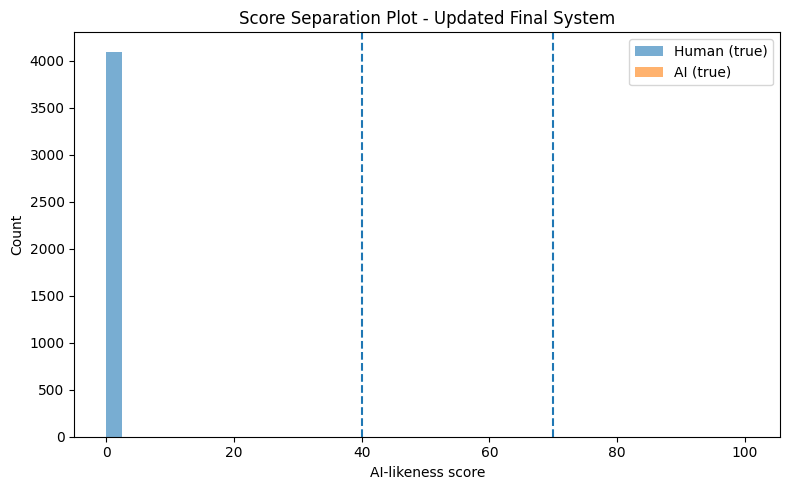

In [13]:
plt.figure(figsize=(8, 5))

human_scores = test_results_df.loc[test_results_df["true_label"] == "Human", "ai_likeness_score"]
ai_scores = test_results_df.loc[test_results_df["true_label"] == "AI", "ai_likeness_score"]

plt.hist(human_scores, bins=20, alpha=0.6, label="Human (true)")
plt.hist(ai_scores, bins=20, alpha=0.6, label="AI (true)")

plt.axvline(40, linestyle="--")
plt.axvline(70, linestyle="--")

plt.xlabel("AI-likeness score")
plt.ylabel("Count")
plt.title("Score Separation Plot - Updated Final System")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
def word_count(text):
    return len(str(text).split())

test_results_df["word_count"] = test_results_df["review_text"].apply(word_count)

median_wc = test_results_df["word_count"].median()
test_results_df["length_group"] = np.where(
    test_results_df["word_count"] <= median_wc,
    "short",
    "long"
)

print("Median test-set word count:", median_wc)
test_results_df[["review_text", "word_count", "length_group"]].head()

Median test-set word count: 78.0


,review_text,word_count,length_group
0,draycott great business hotel stayed draycott ...,28,short
1,We just spent two nights at this hotel and it ...,102,long
2,sixth ave good budget choice downtown really e...,52,short
3,perfect stay stayed property night prior cruis...,73,short
4,"basic ok, great location stag weekend 8 lads r...",28,short


In [15]:
subgroup_rows = []

for group_name, group_df in test_results_df.groupby("length_group"):
    y_true_g = group_df["true_label_binary"].values
    y_pred_g = (group_df["predicted_label"] == "AI").astype(int).values

    acc_g = accuracy_score(y_true_g, y_pred_g)
    prec_g, rec_g, f1_g, _ = precision_recall_fscore_support(
        y_true_g, y_pred_g, average="binary", zero_division=0
    )

    subgroup_rows.append({
        "length_group": group_name,
        "n_reviews": len(group_df),
        "accuracy": acc_g,
        "precision": prec_g,
        "recall": rec_g,
        "f1": f1_g,
        "avg_ai_probability": group_df["ai_probability"].mean(),
        "avg_ai_likeness_score": group_df["ai_likeness_score"].mean(),
    })

subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df

,length_group,n_reviews,accuracy,precision,recall,f1,avg_ai_probability,avg_ai_likeness_score
0,long,2581,1.0,1.0,1.0,1.0,0.225106,22.510655
1,short,2604,1.0,1.0,1.0,1.0,0.194503,19.450461


In [16]:
uncertainty_summary = (
    test_results_df.groupby(["length_group", "uncertainty_band"])
    .size()
    .reset_index(name="count")
)

uncertainty_summary["pct_within_group"] = uncertainty_summary.groupby("length_group")["count"].transform(
    lambda x: 100 * x / x.sum()
)

uncertainty_summary

,length_group,uncertainty_band,count,pct_within_group
0,long,likely AI-generated,581,22.510655
1,long,likely human-written,2000,77.489345
2,short,likely AI-generated,506,19.431644
3,short,likely human-written,2097,80.529954
4,short,uncertain,1,0.038402


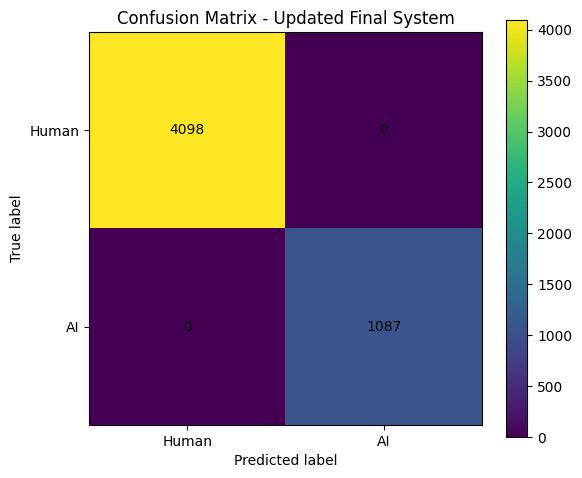

In [17]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Updated Final System")
plt.colorbar()
plt.xticks([0, 1], ["Human", "AI"])
plt.yticks([0, 1], ["Human", "AI"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

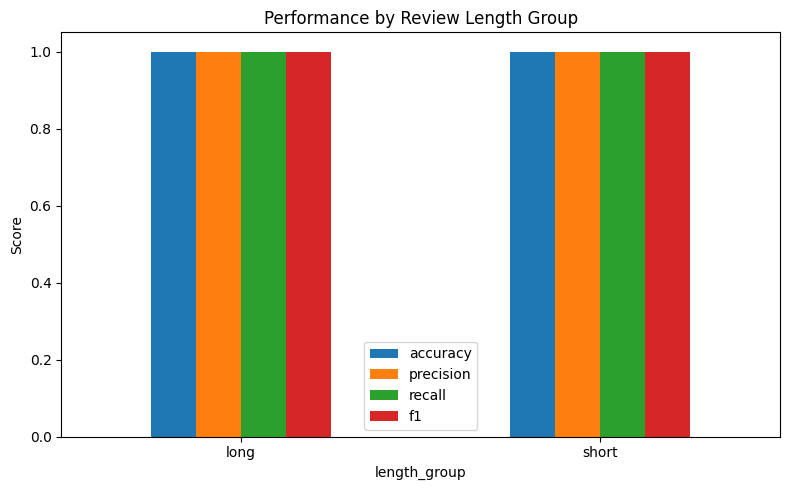

In [18]:
plot_df = subgroup_df.set_index("length_group")[["accuracy", "precision", "recall", "f1"]]

plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Performance by Review Length Group")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
uncertain_cases = test_results_df[test_results_df["uncertainty_band"] == "uncertain"].copy()

print("Number of uncertain cases:", len(uncertain_cases))

uncertain_cases[[
    "review_text",
    "true_label",
    "predicted_label",
    "ai_probability",
    "ai_likeness_score",
    "top_features",
    "explanation"
]].head(10)

Number of uncertain cases: 1


,review_text,true_label,predicted_label,ai_probability,ai_likeness_score,top_features,explanation
4559,beds inhumane hotel fine staff excrutiatingly ...,Human,Human,0.4872,49,"{'capital_letter_ratio': 0.0, 'stopword_ratio'...",The detector assigns an AI probability of 0.48...


In [20]:
print("=" * 90)
print("UPDATED WEEK 4-5 SUMMARY USING DIVERSE DATA")
print("=" * 90)

print("\nSelected model from artifact:", selected_model_name)

print("\nFull updated test performance:")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))

print("\nSubgroup results:")
print(subgroup_df.to_string(index=False))

print("\nUncertainty-band breakdown:")
print(uncertainty_summary.to_string(index=False))

print("""
Interpretation:
- The updated final detector now reflects the diversified AI review dataset rather than the earlier more repetitive synthetic set.
- Logistic regression became less than perfect during retraining, which suggests the diversified AI data made the task somewhat harder.
- The selected random forest model still remains extremely strong, so results should still be interpreted cautiously because residual synthetic cues may remain.
- This notebook updates the Week 4 explanation-chain demo and Week 5 evaluation summary using the newer final artifact.
""")

UPDATED WEEK 4-5 SUMMARY USING DIVERSE DATA

Selected model from artifact: random_forest

Full updated test performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Subgroup results:
length_group  n_reviews  accuracy  precision  recall  f1  avg_ai_probability  avg_ai_likeness_score
        long       2581       1.0        1.0     1.0 1.0            0.225106              22.510655
       short       2604       1.0        1.0     1.0 1.0            0.194503              19.450461

Uncertainty-band breakdown:
length_group     uncertainty_band  count  pct_within_group
        long  likely AI-generated    581         22.510655
        long likely human-written   2000         77.489345
       short  likely AI-generated    506         19.431644
       short likely human-written   2097         80.529954
       short            uncertain      1          0.038402

Interpretation:
- The updated final detector now reflects the diversified AI review dataset rather than the earlier more repeti

In [21]:
updated_week45_outputs = {
    "selected_model_name": selected_model_name,
    "comparison_df": comparison_df,
    "full_test_metrics": {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
    },
    "subgroup_df": subgroup_df,
    "uncertainty_summary": uncertainty_summary,
    "test_results_df": test_results_df,
}

with open("updated_week4_week5_outputs.pkl", "wb") as f:
    pickle.dump(updated_week45_outputs, f)

print("Saved updated_week4_week5_outputs.pkl")

Saved updated_week4_week5_outputs.pkl
